# Feature Engineering

## Import required libraries

In [1]:
import sys 
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_4/credit-risk-model/src'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_4/credit-risk-model/src'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_4\credit-risk-model\src


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import data_loader as ld
import plots as pl
from data_processing import cap_outliers


### Feature Engineering

In [3]:
df = ld.load_data('../data/raw/data.csv')
df_capped = cap_outliers(df, cols=['Amount', 'Value'])
from data_processing import engineer_features
df_engineered = engineer_features(df_capped)
print("Processed data not found; loaded raw data and engineered it as a fallback.")

print(f"Loaded {len(df_engineered)} records with {len(df_engineered.columns)} columns.")
df_engineered.head()

Dataset loaded successfully.
Shape: (95662, 16)
Processed data not found; loaded raw data and engineered it as a fallback.
Loaded 95662 records with 23 columns.


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,...,TransactionStartTime,PricingStrategy,FraudResult,TransactionHour,TransactionDay,TransactionMonth,TransactionYear,DayofWeek,IsWeekend,IsReversal
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,...,2018-11-15 02:18:49+00:00,2,0,2,15,11,2018,3,0,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,...,2018-11-15 02:19:08+00:00,2,0,2,15,11,2018,3,0,1
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,...,2018-11-15 02:44:21+00:00,2,0,2,15,11,2018,3,0,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,...,2018-11-15 03:32:55+00:00,2,0,3,15,11,2018,3,0,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,...,2018-11-15 03:34:21+00:00,2,0,3,15,11,2018,3,0,1


## Aggregate Features

In [4]:
Total_Transaction_Amount = df_engineered.groupby('CustomerId')['Amount'].sum().reset_index()
Average_Transaction_Amount = df_engineered.groupby('CustomerId')['Amount'].mean()
Transaction_Count = df_engineered.groupby('CustomerId')['TransactionId'].count()
std_of_Transaction_Amounts = df_engineered.groupby('CustomerId')['Amount'].std()

print(f'Total Transaction Amount = {Total_Transaction_Amount}')
print(f'Average Transaction Amount = {Average_Transaction_Amount}')
print(f'Transaction_Count = {Transaction_Count}')
print(f'Standard Deviation of Transaction Amounts = {std_of_Transaction_Amounts}')



Total Transaction Amount =            CustomerId    Amount
0        CustomerId_1   -4325.0
1       CustomerId_10   -4325.0
2     CustomerId_1001   14825.0
3     CustomerId_1002    4225.0
4     CustomerId_1003   14825.0
...               ...       ...
3737   CustomerId_992   14825.0
3738   CustomerId_993   14825.0
3739   CustomerId_994  190648.0
3740   CustomerId_996   98725.0
3741   CustomerId_998   68950.0

[3742 rows x 2 columns]
Average Transaction Amount = CustomerId
CustomerId_1      -4325.000000
CustomerId_10     -4325.000000
CustomerId_1001    2965.000000
CustomerId_1002     384.090909
CustomerId_1003    2470.833333
                      ...     
CustomerId_992     2470.833333
CustomerId_993     2965.000000
CustomerId_994     1887.603960
CustomerId_996     5807.352941
CustomerId_998     3134.090909
Name: Amount, Length: 3742, dtype: float64
Transaction_Count = CustomerId
CustomerId_1         1
CustomerId_10        1
CustomerId_1001      5
CustomerId_1002     11
CustomerId_1003  

In [5]:
customer_metrics = df_engineered.groupby('CustomerId')['Amount'].agg(
    total_amount='sum',
    average_amount='mean',
    transaction_count='count',
    amount_std='std'
).reset_index()

print(customer_metrics)

           CustomerId  total_amount  average_amount  transaction_count  \
0        CustomerId_1       -4325.0    -4325.000000                  1   
1       CustomerId_10       -4325.0    -4325.000000                  1   
2     CustomerId_1001       14825.0     2965.000000                  5   
3     CustomerId_1002        4225.0      384.090909                 11   
4     CustomerId_1003       14825.0     2470.833333                  6   
...               ...           ...             ...                ...   
3737   CustomerId_992       14825.0     2470.833333                  6   
3738   CustomerId_993       14825.0     2965.000000                  5   
3739   CustomerId_994      190648.0     1887.603960                101   
3740   CustomerId_996       98725.0     5807.352941                 17   
3741   CustomerId_998       68950.0     3134.090909                 22   

       amount_std  
0             NaN  
1             NaN  
2     5048.285600  
3      560.498966  
4     4597.

In [6]:
from data_processing import apply_label_encoder
df_encoded = apply_label_encoder(df_engineered)

   TransactionId  BatchId  AccountId  SubscriptionId  CustomerId  \
0          78150    46980       2490            3535        2584   
1          75821    31755       3219            2366        2584   
2          39888    60272       2713             996        2806   
3          48738     1797       3351             974        3733   
4          41364    48941       3219            2366        3733   

   CurrencyCode  CountryCode  ProviderId  ProductId  ProductCategory  \
0             0            0           5          1                0   
1             0            0           3         19                2   
2             0            0           5          0                0   
3             0            0           0         11                8   
4             0            0           3         19                2   

   ChannelId  
0          2  
1          1  
2          2  
3          2  
4          1  


## Feature Engineering, Weight of Evidence (WoE), and Information Value (IV)

,feature,iv,predictive_power
0,BatchId,27.649360,Very Strong
1,TransactionId,27.627285,Very Strong
2,TransactionStartTime,27.428836,Very Strong
3,CustomerId,17.428302,Very Strong
4,Value,14.788843,Very Strong
5,AccountId,13.993804,Very Strong
6,SubscriptionId,13.813842,Very Strong
7,Amount,9.087101,Very Strong
8,ProductId,4.856283,Very Strong
9,ProviderId,3.329218,Very Strong


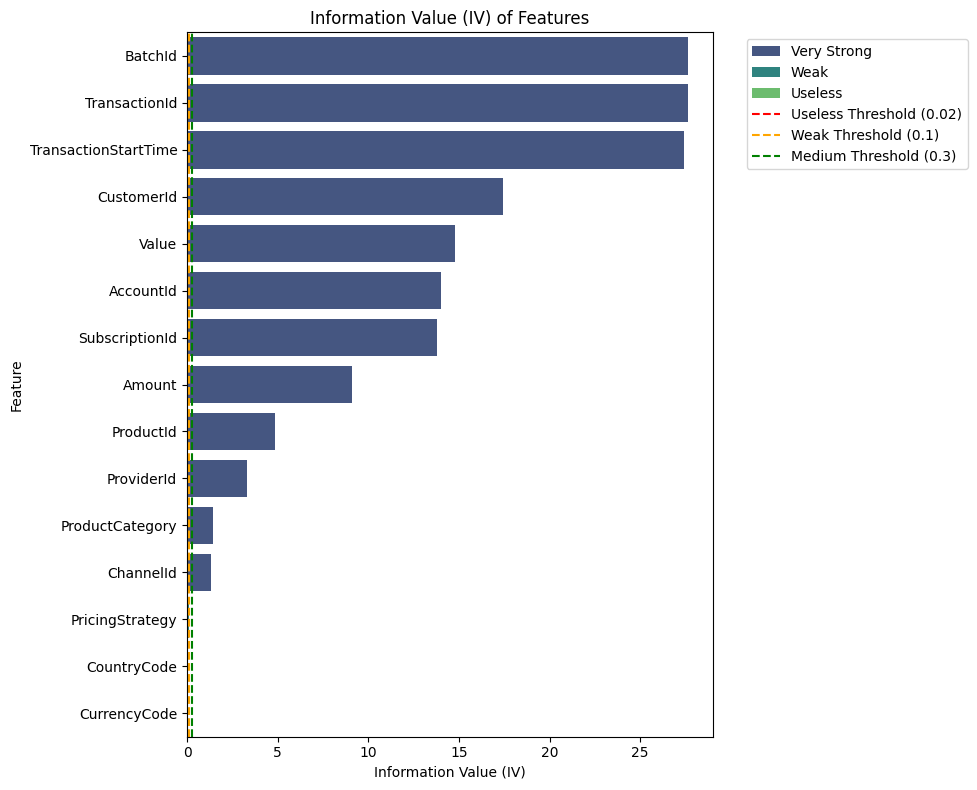

In [7]:
from data_processing import compute_all_iv, encode_woe

# Compute Information Value (IV) for all features
iv_df = compute_all_iv(df_engineered)

# Display the dataframe
from IPython.display import display
display(iv_df)

# IV ranking plot 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(
    data=iv_df,
    x='iv',
    y='feature',
    hue='predictive_power',
    palette='viridis',
    dodge=False,
 )
plt.title('Information Value (IV) of Features')
plt.xlabel('Information Value (IV)')
plt.ylabel('Feature')
plt.axvline(x=0.02, color='red',     linestyle='--', label='Useless Threshold (0.02)')
plt.axvline(x=0.1,  color='orange',  linestyle='--', label='Weak Threshold (0.1)')
plt.axvline(x=0.3,  color='green',   linestyle='--', label='Medium Threshold (0.3)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Apply WoE Encoding

In [8]:
from data_processing import CATEGORICAL_COLS

df_woe, woe_maps = encode_woe(df_engineered, CATEGORICAL_COLS)
woe_cols = [f"{c}_woe" for c in CATEGORICAL_COLS if f"{c}_woe" in df_woe.columns]
all_features = NUMERICAL_COLS = [
    "Amount", "Value", "PricingStrategy"
] + woe_cols

df_woe[all_features + ['FraudResult']].head()



2026-06-03 11:59:37,254 [WARNING] Falling back to custom WoE encoding due to error


,Amount,Value,PricingStrategy,TransactionId_woe,BatchId_woe,AccountId_woe,SubscriptionId_woe,CustomerId_woe,CurrencyCode_woe,CountryCode_woe,ProviderId_woe,ProductId_woe,ProductCategory_woe,ChannelId_woe,TransactionStartTime_woe,FraudResult
0,1000.0,1000.0,2,-7.611645,-7.611645,-11.801299,-11.801299,-12.390767,0.0,0.0,-3.137004,-1.645067,-1.620379,0.472374,-7.611645,0
1,-20.0,20.0,2,-7.611645,-7.611645,-4.134385,-4.189089,-12.390767,0.0,0.0,-2.736867,-4.189242,0.565446,-2.709037,-7.611645,0
2,500.0,500.0,2,-7.611645,-7.611645,-8.304792,-8.304792,-8.304792,0.0,0.0,-3.137004,-15.578924,-1.620379,0.472374,-7.611645,0
3,7075.0,12087.5,2,-7.611645,-7.611645,-10.869740,-10.869740,-11.249230,0.0,0.0,1.618899,0.271622,1.134963,0.472374,-7.611645,0
4,-644.0,644.0,2,-7.611645,-7.611645,-4.134385,-4.189089,-11.249230,0.0,0.0,-2.736867,-4.189242,0.565446,-2.709037,-7.611645,0


In [9]:
# Fit preprocessing pipeline and save processed CSV
import importlib
import data_processing as dp
importlib.reload(dp)
from pathlib import Path
from pathlib import Path

# Load raw data and fit the pipeline
df = dp.load_raw_data('../data/raw/data.csv')
pipeline, df_ready = dp.fit_transform_pipeline(df, use_woe=False)
print('Transformed shape:', df_ready.shape)

# Save processed output
out_path = Path('../data/processed/data_processed.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
df_ready.to_csv(out_path, index=False)
print('Saved processed data to:', out_path)


2026-06-03 12:00:42,238 [INFO] Loading raw data from: ../data/raw/data.csv


Transformed shape: (95662, 27)
Saved processed data to: ..\data\processed\data_processed.csv


In [10]:
import importlib
import data_processing as dp
importlib.reload(dp)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
sns.set(style='whitegrid')


In [11]:
# Load processed if present, otherwise run pipeline on raw data
from pathlib import Path
processed_path = Path('../data/processed/data_processed.csv')
if processed_path.exists():
    df = dp.load_processed_data(str(processed_path))
    print('Loaded processed data from', processed_path)
else:
    raw = dp.load_raw_data('../data/raw/data.csv')
    pipeline, df = dp.fit_transform_pipeline(raw, use_woe=False)
    print('Ran pipeline on raw data')
print('shape:', df.shape)
display(df.head())


2026-06-03 12:00:54,002 [INFO] Loading processed data from: ..\data\processed\data_processed.csv


Loaded processed data from ..\data\processed\data_processed.csv
shape: (95662, 27)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,...,Avg_Trans_Amount,Transaction_Count,Std_Trans_Amount,TransactionHour,TransactionDay,TransactionMonth,TransactionYear,DayofWeek,IsWeekend,IsReversal
0,78150,46980,2490,3535,2584,0,0.0,5,1,0,...,-0.067623,-0.311831,-0.167016,-2.155530,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,-0.815149
1,75821,31755,3219,2366,2584,0,0.0,3,19,2,...,-0.067623,-0.311831,-0.167016,-2.155530,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,1.226769
2,39888,60272,2713,996,2806,0,0.0,5,0,0,...,-0.072568,-0.444993,-0.201209,-2.155530,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,-0.815149
3,48738,1797,3351,974,3733,0,0.0,0,11,8,...,-0.008155,-0.404020,-0.008243,-1.949214,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,-0.815149
4,41364,48941,3219,2366,3733,0,0.0,3,19,2,...,-0.008155,-0.404020,-0.008243,-1.949214,-0.100739,0.848684,-0.994246,-0.006389,-0.510703,1.226769


In [12]:
# Summary statistics and sample categorical counts
print('Numerical summary:')
display(df.describe().T)
cat_cols = [c for c in (dp.CATEGORICAL_COLS if hasattr(dp, 'CATEGORICAL_COLS') else df.select_dtypes('object').columns.tolist()) if c in df.columns]
print('Categorical samples:')
for c in cat_cols[:6]:
    print('---', c)
    display(df[c].value_counts().head())


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
TransactionId,95662.0,4.783050e+04,27615.385063,0.000000,23915.250000,47830.500000,71745.750000,95661.000000
BatchId,95662.0,4.740604e+04,27374.865336,0.000000,23684.250000,47418.500000,71095.750000,94808.000000
AccountId,95662.0,2.332943e+03,1021.762070,0.000000,1548.000000,2728.000000,3219.000000,3632.000000
SubscriptionId,95662.0,2.059692e+03,884.139292,0.000000,1538.000000,2366.000000,2467.000000,3626.000000
CustomerId,95662.0,1.961152e+03,1046.685310,0.000000,1131.000000,1969.000000,2891.000000,3741.000000
CurrencyCode,95662.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CountryCode,95662.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ProviderId,95662.0,3.657157e+00,1.309014,0.000000,3.000000,4.000000,5.000000,5.000000
ProductId,95662.0,1.238879e+01,7.217021,0.000000,6.000000,16.000000,19.000000,22.000000
ProductCategory,95662.0,1.238726e+00,1.550262,0.000000,0.000000,2.000000,2.000000,8.000000


Categorical samples:
--- TransactionId


TransactionId
78150    1
75821    1
39888    1
48738    1
41364    1
Name: count, dtype: int64

--- BatchId


...

SubscriptionId
2366    32630
2859     4457
311      1105
1720     1070
2789      965
Name: count, dtype: int64

--- CustomerId


CustomerId
3478    4091
1969    2085
3390    1869
66       784
2271     778
Name: count, dtype: int64

--- CurrencyCode


CurrencyCode
0    95662
Name: count, dtype: int64

In [ ]:
# Example numeric before/after plots for first few numeric features
# 1. Identify target columns first
num_cols = df.select_dtypes(include=['number']).columns.tolist()
sample_nums = num_cols[:4]

if not sample_nums:
    print('No numeric columns found')
else:
    # 2. Check if raw data is already loaded in the environment to avoid re-reading disk
    if 'raw' not in locals() or raw is None:
        try:
            # OPTIMIZATION: If possible, modify this to only load `sample_nums` columns
            print("Loading raw data from disk...")
            raw = dp.load_raw_data('../data/raw/data.csv')
        except Exception as e:
            print(f"Could not load raw data: {e}")
            raw = None

    n = len(sample_nums)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3*n))
    
    # Handle the edge case where n=1 (matplotlib returns a 1D array instead of 2D)
    if n == 1:
        axes = axes.reshape(1, 2)

    # 3. Define a safe max sample size for plotting speed
    MAX_PLOT_ROWS = 100_000 

    for i, c in enumerate(sample_nums):
        # --- Plot Raw Data ---
        if raw is not None and c in raw.columns:
            plot_data_raw = raw[c].dropna()
            # OPTIMIZATION: Downsample if the dataset is massive
            if len(plot_data_raw) > MAX_PLOT_ROWS:
                plot_data_raw = plot_data_raw.sample(n=MAX_PLOT_ROWS, random_state=42)
                
            axes[i,0].hist(plot_data_raw, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            axes[i,0].set_title(f'Raw {c} (Sampled)')
        else:
            axes[i,0].text(0.5, 0.5, 'raw missing or unaligned', ha='center', va='center')
            axes[i,0].set_title(f'Raw {c} (Missing)')
            
        # --- Plot Processed Data ---
        plot_data_proc = df[c].dropna()
        # OPTIMIZATION: Downsample processed data as well
        if len(plot_data_proc) > MAX_PLOT_ROWS:
            plot_data_proc = plot_data_proc.sample(n=MAX_PLOT_ROWS, random_state=42)
            
        axes[i,1].hist(plot_data_proc, bins=30, color='salmon', edgecolor='black', alpha=0.7)
        axes[i,1].set_title(f'Processed {c} (Sampled)')

    plt.tight_layout()
    plt.show()


2026-06-03 12:00:55,747 [INFO] Loading raw data from: ../data/raw/data.csv


KeyboardInterrupt: 

In [14]:
# Compute Information Value (IV) table if available
try:
    iv_df = dp.compute_all_iv(df)
    display(iv_df.sort_values('iv', ascending=False).head(30))
except Exception as e:
    print('compute_all_iv failed:', e)


,feature,iv,predictive_power
0,TransactionId,1.097095e+06,Very Strong
1,BatchId,1.086817e+06,Very Strong
2,TransactionStartTime,1.083671e+06,Very Strong
3,AccountId,3.552240e+04,Very Strong
4,SubscriptionId,3.546473e+04,Very Strong
5,CustomerId,3.537059e+04,Very Strong
6,ProductId,1.300055e+02,Very Strong
7,ProductCategory,4.428590e+01,Very Strong
8,Value,1.947719e+01,Very Strong
9,ProviderId,1.737429e+01,Very Strong


In [ ]:
# Show default rate by top categorical column
cat_cols = [c for c in (dp.CATEGORICAL_COLS if hasattr(dp, 'CATEGORICAL_COLS') else df.select_dtypes('object').columns.tolist()) if c in df.columns]
if 'FraudResult' in df.columns and cat_cols:
    col = cat_cols[0]
    print('Using categorical column:', col)
    grouped = df.groupby(col)['FraudResult'].mean().sort_values()
    display(grouped.to_frame('FraudResult'))
    grouped.plot(kind='bar', figsize=(10,4))
    plt.title(f'FraudResult rate by {col}')
    plt.show()
else:
    print('No default column or categorical columns available')


Using categorical column: TransactionId


,FraudResult
TransactionId,
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
95657,0.0
95658,0.0
95659,0.0


In [ ]:
# Save a processed snapshot from notebook
from pathlib import Path
out = Path('../data/processed/data_processed_from_notebook.csv')
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)
print('Saved processed snapshot to', out)
